In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# import os
# from datetime import datetime
# import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")

In [3]:
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [4]:
df.tail()

,Date,Temp
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7
3649,1990-12-31,13.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB


In [6]:
df.describe()

,Temp
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


In [7]:
df["Date"]=pd.to_datetime(df["Date"],format='%Y-%m-%d')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3650 non-null   datetime64[ns]
 1   Temp    3650 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB


In [9]:
df.set_index("Date",inplace=True)

In [10]:
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


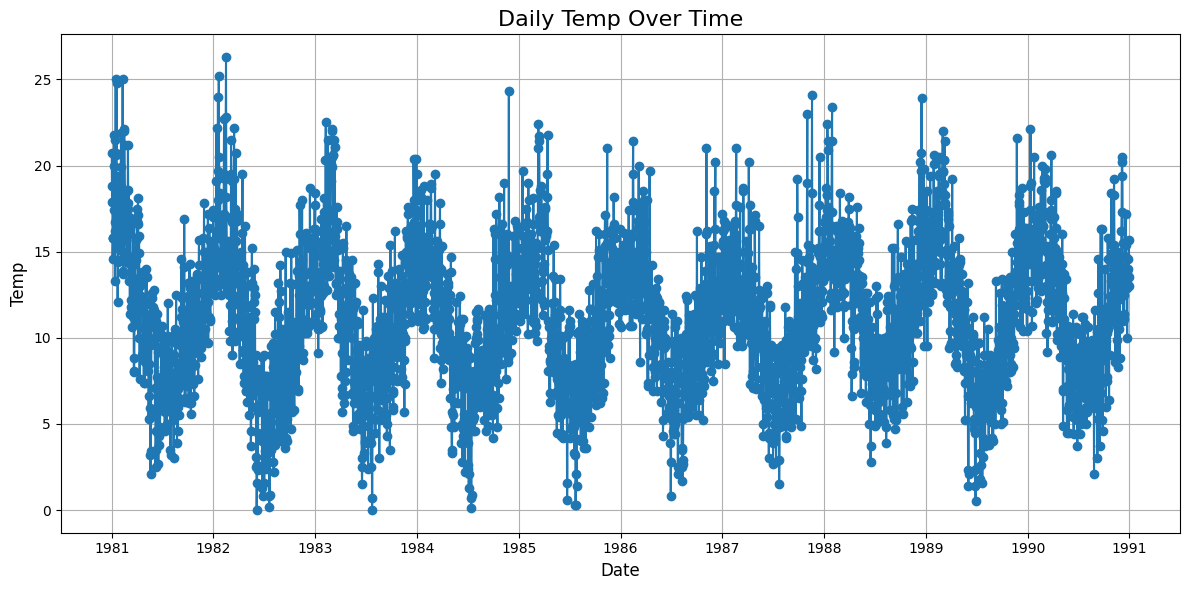

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Temp'], marker='o', linestyle='-')
plt.title('Daily Temp Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temp', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
df_1990=df["1990-01-01":"1990-12-31"]

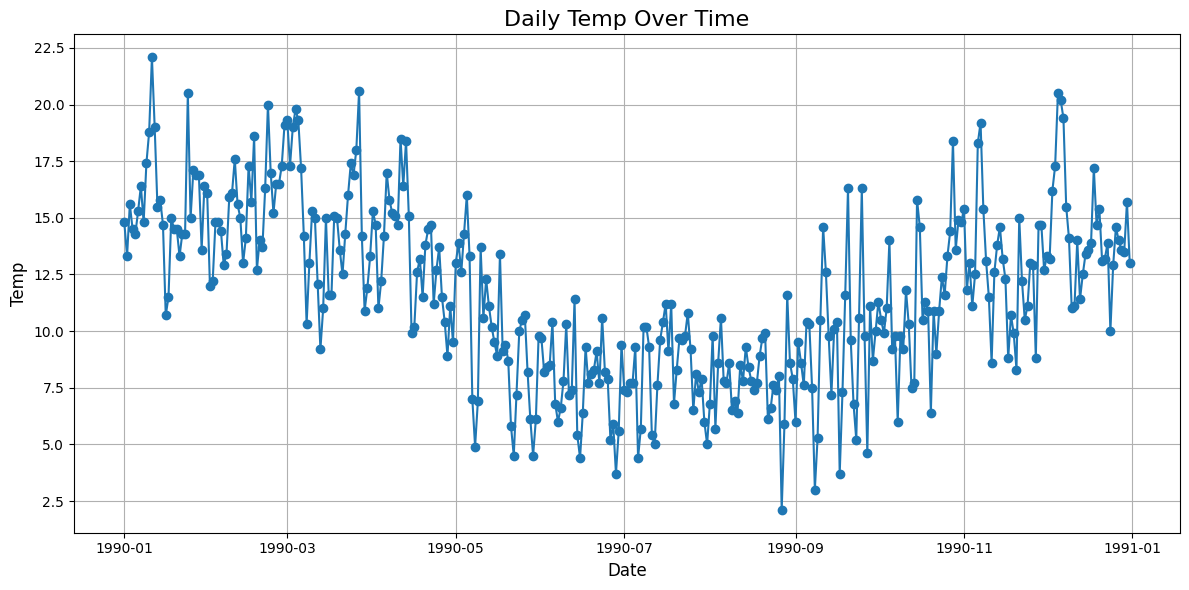

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(df_1990.index, df_1990['Temp'], marker='o', linestyle='-')
plt.title('Daily Temp Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temp', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# #3 day Moving average
# df["ma_rolling_3"]=df["Temp"].rolling(3).mean()

In [17]:
df.head(10)

,Temp,ma_rolling_3
Date,,
1981-01-01,20.7,NaN
1981-01-02,17.9,NaN
1981-01-03,18.8,19.133333
1981-01-04,14.6,17.100000
1981-01-05,15.8,16.400000
1981-01-06,15.8,15.400000
1981-01-07,15.8,15.800000
1981-01-08,17.4,16.333333
1981-01-09,21.8,18.333333


In [14]:
#3 day Moving average
df["ma_rolling_3"]=df["Temp"].rolling(3).mean().shift(1)

In [16]:
df

,Temp,ma_rolling_3
Date,,
1981-01-01,20.7,NaN
1981-01-02,17.9,NaN
1981-01-03,18.8,NaN
1981-01-04,14.6,19.133333
1981-01-05,15.8,17.100000
...,...,...
1990-12-27,14.0,12.500000
1990-12-28,13.6,13.833333
1990-12-29,13.5,14.066667


In [17]:
# 7 day Moving Average
df["ma_rolling_7"]=df["Temp"].rolling(7).mean().shift(1)

In [18]:
# 14 day Moving Average
df["ma_rolling_14"]=df["Temp"].rolling(14).mean().shift(1)

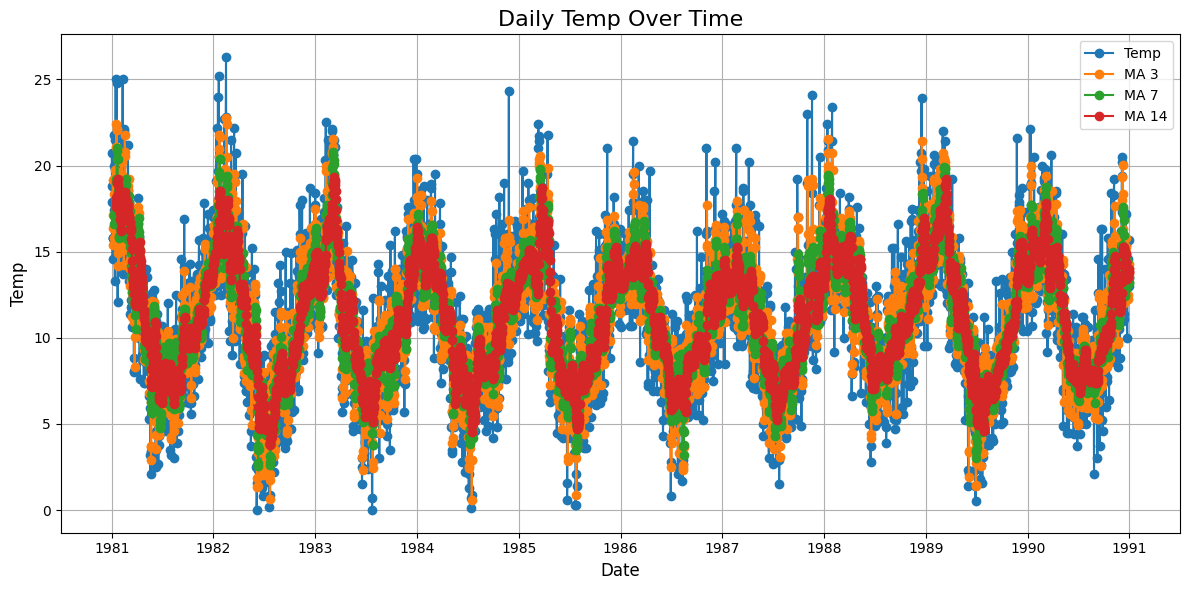

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Temp'], marker='o', linestyle='-')
plt.plot(df.index, df['ma_rolling_3'], marker='o', linestyle='-')
plt.plot(df.index, df['ma_rolling_7'], marker='o', linestyle='-')
plt.plot(df.index, df['ma_rolling_14'], marker='o', linestyle='-')
plt.legend(['Temp', 'MA 3', 'MA 7', 'MA 14'])
plt.title('Daily Temp Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temp', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error

In [21]:
df.dropna(inplace=True)
mean_absolute_error(df["Temp"],df["ma_rolling_3"])

2.2254767143381002

In [22]:
mean_absolute_error(df["Temp"],df["ma_rolling_7"])

2.1920870658494422

In [23]:
mean_absolute_error(df["Temp"],df["ma_rolling_14"])

2.202445780292315

In [24]:
df_1990=df["1990-01-01":"1990-12-31"]

In [25]:
mean_absolute_error(df_1990["Temp"],df_1990["ma_rolling_3"])

2.132054794520548

In [26]:
df.tail()

,Temp,ma_rolling_3,ma_rolling_7,ma_rolling_14
Date,,,,
1990-12-27,14.0,12.500000,13.300000,13.557143
1990-12-28,13.6,13.833333,13.100000,13.742857
1990-12-29,13.5,14.066667,13.171429,13.821429
1990-12-30,15.7,13.700000,13.214286,13.828571
1990-12-31,13.0,14.266667,13.471429,13.978571


In [ ]:
df_1990["Temp"].mean()

np.float64(11.66958904109589)

In [ ]:
df_1990_dec=df["1990-12-01":"1990-12-31"]

In [ ]:
mean_absolute_error(df_1990_dec["Temp"],df_1990_dec["ma_rolling_3"])

1.813978494623656

In [ ]:
# Custom function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    """Calculates the Mean Absolute Percentage Error (MAPE)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
mean_absolute_percentage_error(df_1990_dec["Temp"],df_1990_dec["ma_rolling_3"])

np.float64(12.832798232549198)